In [1]:
import mysql.connector
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')
def generate_market_basket_data():
    """Generate synthetic transaction data for market basket analysis"""
    conn = mysql.connector.connect(
        host="localhost",
        user="root",  
        password="Password123",  
        database="market_basket"
    )
    cursor = conn.cursor()
    try:
        cursor.execute("SET FOREIGN_KEY_CHECKS = 0")
        cursor.execute("TRUNCATE TABLE transaction_items")
        cursor.execute("TRUNCATE TABLE transactions")
        cursor.execute("TRUNCATE TABLE customers")
        cursor.execute("TRUNCATE TABLE products")
        cursor.execute("SET FOREIGN_KEY_CHECKS = 1")
        print("✓ Cleared existing data")
    except Exception as e:
        print(f"⚠️ Could not clear tables: {e}")
    print("\nGenerating products...")
    
    products_data = [
        ('Milk', 'Grocery', 'Dairy', 3.99, 2.50),
        ('Bread', 'Grocery', 'Bakery', 2.49, 1.20),
        ('Eggs', 'Grocery', 'Dairy', 4.99, 3.00),
        ('Butter', 'Grocery', 'Dairy', 5.99, 3.50),
        ('Cheese', 'Grocery', 'Dairy', 6.99, 4.00),
        ('Yogurt', 'Grocery', 'Dairy', 3.49, 2.00),
        ('Creamer', 'Grocery', 'Dairy', 3.99, 2.20),
        ('Chicken', 'Grocery', 'Meat', 8.99, 5.50),
        ('Beef', 'Grocery', 'Meat', 12.99, 8.00),
        ('Pork', 'Grocery', 'Meat', 9.99, 6.00),
        ('Salmon', 'Grocery', 'Seafood', 15.99, 10.00),
        ('Turkey', 'Grocery', 'Meat', 14.99, 9.00),
        ('Apples', 'Produce', 'Fruits', 2.99, 1.50),
        ('Bananas', 'Produce', 'Fruits', 1.49, 0.80),
        ('Oranges', 'Produce', 'Fruits', 3.49, 2.00),
        ('Strawberries', 'Produce', 'Fruits', 4.99, 3.00),
        ('Grapes', 'Produce', 'Fruits', 5.99, 3.50),
        ('Lemons', 'Produce', 'Fruits', 1.99, 1.00),
        ('Apples', 'Produce', 'Fruits', 2.99, 1.50),
        ('Avocado', 'Produce', 'Vegetables', 2.49, 1.50),
        ('Tomatoes', 'Produce', 'Vegetables', 3.49, 2.00),
        ('Onions', 'Produce', 'Vegetables', 1.99, 1.00),
        ('Potatoes', 'Produce', 'Vegetables', 2.99, 1.50),
        ('Lettuce', 'Produce', 'Vegetables', 1.99, 1.00),
        ('Broccoli', 'Produce', 'Vegetables', 2.99, 1.50),
        ('Asparagus', 'Produce', 'Vegetables', 3.99, 2.00),
        ('Cucumber', 'Produce', 'Vegetables', 1.49, 0.80),
        ('Coffee', 'Beverages', 'Hot Drinks', 8.99, 5.00),
        ('Tea', 'Beverages', 'Hot Drinks', 6.99, 4.00),
        ('Orange Juice', 'Beverages', 'Juices', 4.99, 2.50),
        ('Apple Juice', 'Beverages', 'Juices', 3.99, 2.00),
        ('Soda', 'Beverages', 'Soft Drinks', 2.49, 1.20),
        ('Energy Drink', 'Beverages', 'Soft Drinks', 3.49, 1.80),
        ('Wine', 'Beverages', 'Alcoholic', 15.99, 10.00),
        ('Beer', 'Beverages', 'Alcoholic', 10.99, 6.00),
        ('Water', 'Beverages', 'Bottled', 1.99, 0.80),
        ('Chips', 'Snacks', 'Salty', 3.99, 2.00),
        ('Cookies', 'Snacks', 'Sweet', 4.99, 2.50),
        ('Chocolate', 'Snacks', 'Sweet', 2.99, 1.50),
        ('Candy', 'Snacks', 'Sweet', 1.99, 1.00),
        ('Nuts', 'Snacks', 'Healthy', 6.99, 4.00),
        ('Granola Bars', 'Snacks', 'Healthy', 4.99, 2.50),
        ('Crackers', 'Snacks', 'Salty', 3.49, 1.80),
        ('Dog Treats', 'Snacks', 'Pet', 5.99, 3.00),
        ('Detergent', 'Household', 'Cleaning', 12.99, 8.00),
        ('Soap', 'Household', 'Bathroom', 3.99, 2.00),
        ('Shampoo', 'Household', 'Bathroom', 7.99, 4.50),
        ('Toothpaste', 'Household', 'Bathroom', 4.99, 2.50),
        ('Paper Towels', 'Household', 'Kitchen', 8.99, 5.00),
        ('Trash Bags', 'Household', 'Kitchen', 6.99, 4.00),
        ('Cat Litter', 'Household', 'Pets', 14.99, 8.00),
        ('Croissant', 'Bakery', 'Pastries', 3.49, 1.80),
        ('Muffin', 'Bakery', 'Pastries', 2.99, 1.50),
        ('Cake', 'Bakery', 'Cakes', 15.99, 8.00),
        ('Pie', 'Bakery', 'Cakes', 12.99, 6.50),
        ('Pumpkin Pie', 'Bakery', 'Cakes', 14.99, 7.50),
        ('Jam', 'Bakery', 'Spread', 4.99, 2.50),
        ('Sugar', 'Bakery', 'Baking', 3.99, 2.00),
        ('Flour', 'Bakery', 'Baking', 4.99, 2.50),
        ('Chocolate Chips', 'Bakery', 'Baking', 3.99, 2.00),
        ('Stuffing', 'Bakery', 'Baking', 2.99, 1.50),
        ('Ice Cream', 'Frozen', 'Desserts', 5.99, 3.00),
        ('Frozen Pizza', 'Frozen', 'Meals', 7.99, 4.50),
        ('Frozen Vegetables', 'Frozen', 'Vegetables', 3.99, 2.00),
        ('Vitamins', 'Health', 'Supplements', 19.99, 12.00),
        ('Pain Reliever', 'Health', 'Medicine', 8.99, 5.00),
        ('Dog Food', 'Pet', 'Food', 25.99, 15.00),
        ('Cat Food', 'Pet', 'Food', 20.99, 12.00),
        ('Pet Toys', 'Pet', 'Accessories', 9.99, 5.00),
        ('USB Cable', 'Electronics', 'Accessories', 9.99, 4.00),
        ('Phone Charger', 'Electronics', 'Accessories', 19.99, 10.00),
        ('Earphones', 'Electronics', 'Audio', 29.99, 15.00),
        ('Pasta', 'Grocery', 'Pasta', 2.99, 1.50),
        ('Rice', 'Grocery', 'Grains', 4.99, 2.50),
        ('Tomato Sauce', 'Grocery', 'Sauces', 3.99, 2.00),
        ('Cranberry Sauce', 'Grocery', 'Sauces', 4.99, 2.50),
        ('Sandwich Bread', 'Grocery', 'Bakery', 3.49, 1.80),
    ]
    seen = set()
    unique_products = []
    for product in products_data:
        if product[0] not in seen:
            seen.add(product[0])
            unique_products.append(product)
    
    products_data = unique_products
    cursor.executemany("""
        INSERT INTO products (product_name, category, sub_category, price, cost)
        VALUES (%s, %s, %s, %s, %s)
    """, products_data)
    conn.commit()
    print(f"✓ Inserted {len(products_data)} products")
    cursor.execute("SELECT product_id, product_name, price FROM products")
    product_data = cursor.fetchall()
    product_names = {p[1]: p[0] for p in product_data}
    product_prices = {p[0]: p[2] for p in product_data}
    all_product_names = list(product_names.keys())
    print("\nGenerating customers...")
    
    first_names = ['John', 'Emma', 'Michael', 'Sophia', 'William', 'Olivia', 'James', 'Ava', 
                   'Robert', 'Isabella', 'David', 'Mia', 'Richard', 'Charlotte', 'Joseph', 
                   'Amelia', 'Thomas', 'Harper', 'Charles', 'Evelyn', 'Daniel', 'Abigail',
                   'Matthew', 'Emily', 'Anthony', 'Elizabeth', 'Mark', 'Sofia', 'Donald', 'Avery']
    
    last_names = ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia', 'Miller', 'Davis',
                  'Rodriguez', 'Martinez', 'Hernandez', 'Lopez', 'Wilson', 'Anderson', 'Thomas',
                  'Taylor', 'Moore', 'Jackson', 'Martin', 'Lee', 'Perez', 'Thompson', 'White',
                  'Harris', 'Sanchez', 'Clark', 'Ramirez', 'Lewis', 'Robinson', 'Walker']
    
    cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Philadelphia', 
              'San Antonio', 'San Diego', 'Dallas', 'Austin', 'Boston', 'Seattle', 'Denver',
              'Miami', 'Atlanta', 'Portland', 'Detroit', 'Memphis', 'Nashville', 'Baltimore']
    
    membership_types = ['Basic', 'Silver', 'Gold', 'Platinum']
    
    customers = []
    for i in range(500):
        first_name = random.choice(first_names)
        last_name = random.choice(last_names)
        name = f"{first_name} {last_name}"
        email = f"{first_name.lower()}.{last_name.lower()}@email.com"
        join_date = datetime.now() - timedelta(days=random.randint(1, 730))
        
        customers.append((
            name,
            email,
            join_date.date(),
            random.randint(18, 75),
            random.choice(['Male', 'Female']),
            random.choice(cities),
            random.choice(membership_types)
        ))
    
    cursor.executemany("""
        INSERT INTO customers (customer_name, email, join_date, age, gender, city, membership_type)
        VALUES (%s, %s, %s, %s, %s, %s, %s)
    """, customers)
    conn.commit()
    print(f"✓ Inserted {len(customers)} customers")
    cursor.execute("SELECT customer_id FROM customers")
    customer_ids = [row[0] for row in cursor.fetchall()]
    print("\nGenerating transactions...")
    
    product_bundles = [
        ['Milk', 'Bread', 'Eggs', 'Butter'],
        ['Coffee', 'Croissant', 'Butter'],
        ['Tea', 'Muffin', 'Jam'],
        ['Chicken', 'Potatoes', 'Onions', 'Tomatoes'],
        ['Beef', 'Pasta', 'Tomato Sauce'],
        ['Salmon', 'Asparagus', 'Lemons'],
        ['Pork', 'Apples', 'Onions'],
        ['Pasta', 'Tomato Sauce', 'Cheese'],
        ['Chips', 'Soda', 'Cookies'],
        ['Nuts', 'Energy Drink', 'Granola Bars'],
        ['Cookies', 'Milk', 'Chocolate'],
        ['Wine', 'Cheese', 'Crackers'],
        ['Beer', 'Chips', 'Soda'],
        ['Yogurt', 'Granola Bars', 'Strawberries'],
        ['Avocado', 'Lettuce', 'Tomatoes', 'Cucumber'],
        ['Salmon', 'Broccoli', 'Rice'],
        ['Detergent', 'Paper Towels', 'Trash Bags'],
        ['Soap', 'Shampoo', 'Toothpaste'],
        ['Cookies', 'Candy', 'Chocolate', 'Orange Juice'],
        ['Coffee', 'Milk', 'Sugar', 'Creamer'],
        ['Flour', 'Sugar', 'Eggs', 'Butter', 'Chocolate Chips'],
        
        # Pet owner bundle
        ['Dog Food', 'Dog Treats', 'Pet Toys'],
        ['Cat Food', 'Cat Litter', 'Pet Toys'],
        
        # Office snack bundle
        ['Coffee', 'Tea', 'Sugar', 'Cookies'],
        
        # Picnic bundle
        ['Sandwich Bread', 'Lettuce', 'Tomatoes', 'Chips', 'Soda'],
        
        # Sporty bundle
        ['Energy Drink', 'Granola Bars', 'Bananas', 'Water'],
        
        # Holiday bundle
        ['Turkey', 'Stuffing', 'Cranberry Sauce', 'Pumpkin Pie'],
        
        # Italian bundle
        ['Pasta', 'Tomato Sauce', 'Cheese', 'Wine'],
        
        # BBQ bundle
        ['Beef', 'Soda', 'Chips', 'Crackers'],
        
        # Breakfast on-the-go
        ['Coffee', 'Granola Bars', 'Bananas'],
        
        # Movie night
        ['Soda', 'Chips', 'Chocolate', 'Candy'],
    ]
    
    # Filter bundles to only include products that exist
    valid_bundles = []
    for bundle in product_bundles:
        valid_bundle = [item for item in bundle if item in product_names]
        if len(valid_bundle) >= 2:  # Keep bundles with at least 2 products
            valid_bundles.append(valid_bundle)
    
    print(f"✓ Created {len(valid_bundles)} valid product bundles")
    
    transactions = []
    transaction_items = []
    transaction_counter = 1
    
    start_date = datetime.now() - timedelta(days=365)
    end_date = datetime.now()
    
    for customer_id in customer_ids:
        # Each customer has 3-20 transactions
        num_transactions = random.randint(3, 20)
        
        # Generate transaction dates
        dates = []
        for _ in range(num_transactions):
            days_range = (end_date - start_date).days
            random_days = random.randint(0, days_range)
            trans_date = start_date + timedelta(days=random_days)
            dates.append(trans_date)
        
        dates.sort()
        
        for trans_date in dates:
            # Determine how many items in this transaction (2-10 items)
            num_items = random.randint(2, 10)
            
            # Randomly choose to use a bundle or individual items
            use_bundle = random.random() < 0.35  # 35% chance of using a bundle
            
            items_in_transaction = []
            
            if use_bundle and valid_bundles:
                # Pick a random valid bundle
                bundle = random.choice(valid_bundles)
                # Take 2-5 items from the bundle
                bundle_size = random.randint(2, min(5, len(bundle)))
                chosen_items = random.sample(bundle, bundle_size)
                items_in_transaction.extend(chosen_items)
                
                # Add some random items to make it more realistic
                if random.random() < 0.3 and len(items_in_transaction) < num_items:
                    max_extra = min(num_items - len(items_in_transaction), 3)
                    extra_items = random.sample(all_product_names, 
                                               min(max_extra, len(all_product_names)))
                    items_in_transaction.extend(extra_items)
            else:
                # Pick random items
                num_to_select = min(num_items, len(all_product_names))
                items_in_transaction = random.sample(all_product_names, num_to_select)
            
            # Remove duplicates
            items_in_transaction = list(set(items_in_transaction))
            
            # Calculate total amount
            total_amount = 0
            for item_name in items_in_transaction:
                if item_name in product_names:  # Extra safety check
                    product_id = product_names[item_name]
                    price = product_prices[product_id]
                    quantity = random.randint(1, 3)
                    total_amount += price * quantity
                    
                    transaction_items.append((
                        transaction_counter,
                        product_id,
                        quantity,
                        price,
                        random.choice([0, 0, 0, 5, 10])  # Discount %
                    ))
            
            # Payment method based on total
            if total_amount > 100:
                payment = 'Credit Card'
            elif total_amount > 50:
                payment = random.choice(['Credit Card', 'Debit Card'])
            else:
                payment = random.choice(['Cash', 'Debit Card', 'Mobile Wallet'])
            
            transactions.append((
                customer_id,
                trans_date,
                round(total_amount, 2),
                payment,
                random.choice(['Store A', 'Store B', 'Store C', 'Online'])
            ))
            
            transaction_counter += 1
    
    # Insert transactions
    if transactions:
        cursor.executemany("""
            INSERT INTO transactions (customer_id, transaction_date, total_amount, payment_method, store_location)
            VALUES (%s, %s, %s, %s, %s)
        """, transactions)
        conn.commit()
        print(f"✓ Inserted {len(transactions)} transactions")
    
    # Insert transaction items
    if transaction_items:
        cursor.executemany("""
            INSERT INTO transaction_items (transaction_id, product_id, quantity, price_per_unit, discount)
            VALUES (%s, %s, %s, %s, %s)
        """, transaction_items)
        conn.commit()
        print(f"✓ Inserted {len(transaction_items)} transaction items")
    
    cursor.close()
    conn.close()
    
    print("\n✅ Data generation completed successfully!")
    print(f"   - Customers: {len(customers)}")
    print(f"   - Products: {len(products_data)}")
    print(f"   - Transactions: {len(transactions)}")
    print(f"   - Transaction Items: {len(transaction_items)}")

# ============================================
# RUN DATA GENERATION
# ============================================

if __name__ == "__main__":
    print("🚀 Starting Market Basket Data Generation...")
    print("="*60)
    generate_market_basket_data()
    print("\n" + "="*60)
    print("✅ Data generation complete! Ready for analysis.")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



🚀 Starting Market Basket Data Generation...
✓ Cleared existing data

Generating products...
✓ Inserted 76 products

Generating customers...
✓ Inserted 500 customers

Generating transactions...
✓ Created 31 valid product bundles
✓ Inserted 5659 transactions
✓ Inserted 28639 transaction items

✅ Data generation completed successfully!
   - Customers: 500
   - Products: 76
   - Transactions: 5659
   - Transaction Items: 28639

✅ Data generation complete! Ready for analysis.


🚀 Starting Market Basket Analysis...

1. Loading transaction data from MySQL...
   Loaded 28639 transaction items

2. Preparing transaction data...
✓ Loaded 5659 transactions
✓ Total unique products: 76

3. Running Apriori algorithm...
Analyzing 5659 transactions...
✓ Encoded 5659 transactions with 76 products

Running Apriori with min_support=0.01...
✓ Found 172 frequent itemsets

Generating rules with min_confidence=0.3, min_lift=1.2...
✓ Generated 7 association rules

4. Analyzing results...

MARKET BASKET ANALYSIS RESULTS

📊 TOP FREQUENT ITEMSETS:
--------------------------------------------------------------------------------
  Support: 0.097 | Items: Granola Bars
  Support: 0.097 | Items: Chips
  Support: 0.096 | Items: Soda
  Support: 0.093 | Items: Coffee
  Support: 0.089 | Items: Cookies
  Support: 0.084 | Items: Cheese
  Support: 0.084 | Items: Pasta
  Support: 0.083 | Items: Tomato Sauce
  Support: 0.081 | Items: Tomatoes
  Support: 0.081 | Items: Milk

🔗 TOP ASSOCIATION RUL

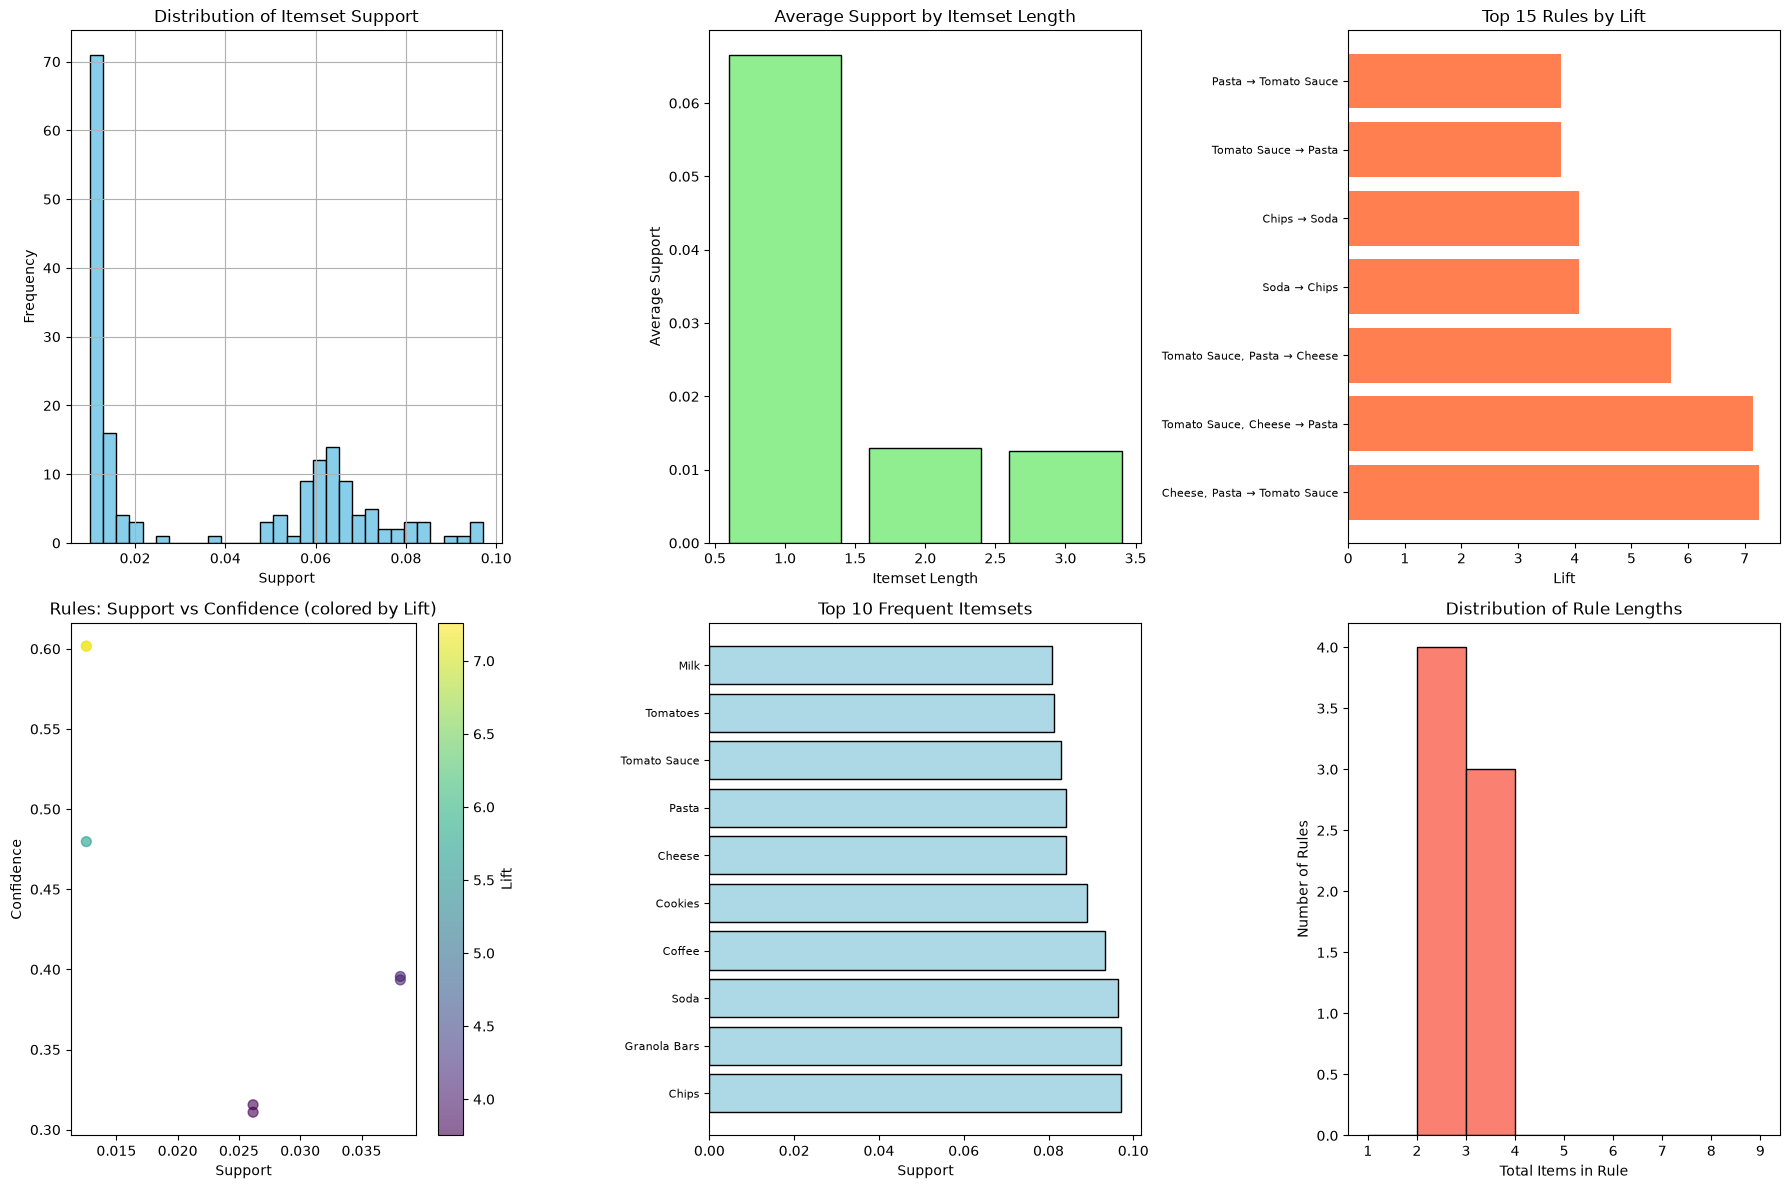

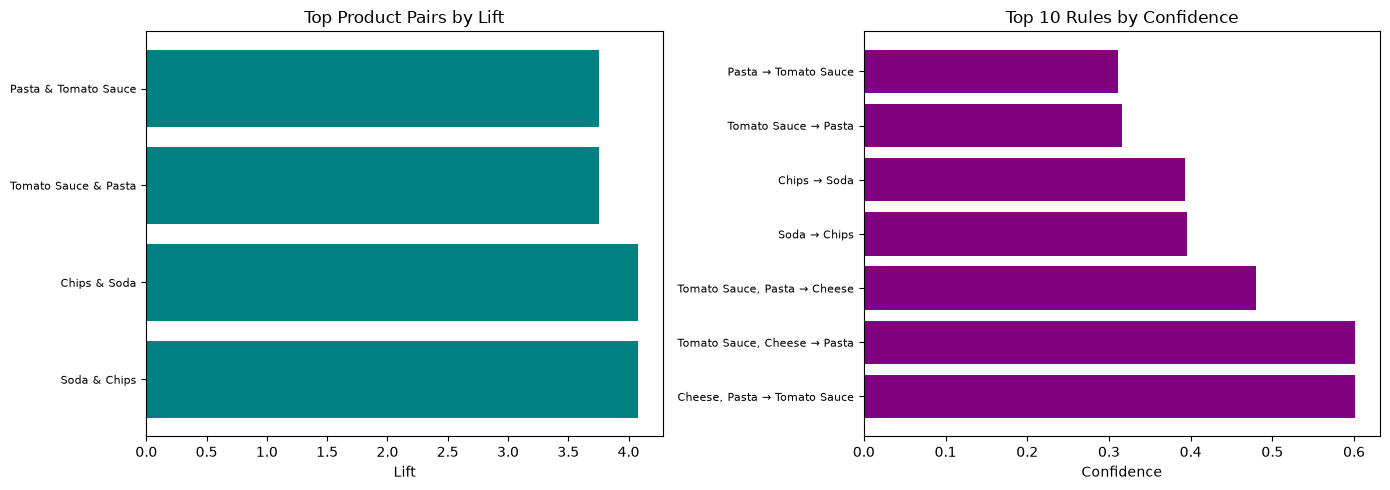


6. Generating business recommendations...

💡 BUSINESS RECOMMENDATIONS

1. 📦 PRODUCT BUNDLING OPPORTUNITIES:
--------------------------------------------------------------------------------
  No strong bundling opportunities found with current thresholds.

2. 🎯 CROSS-SELLING RECOMMENDATIONS:
--------------------------------------------------------------------------------
  ✓ Customers who buy 'Soda' often also buy 'Chips'
    Confidence: 0.40, Lift: 4.08
  ✓ Customers who buy 'Chips' often also buy 'Soda'
    Confidence: 0.39, Lift: 4.08
  ✓ Customers who buy 'Tomato Sauce' often also buy 'Pasta'
    Confidence: 0.32, Lift: 3.75
  ✓ Customers who buy 'Pasta' often also buy 'Tomato Sauce'
    Confidence: 0.31, Lift: 3.75

5. 📈 STRATEGIC RECOMMENDATIONS:
--------------------------------------------------------------------------------

  1. Create Pre-Bundled Packages
     Action: Create combo deals for the top product pairs found above
     Expected Benefit: Increase average order value 

In [3]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import mysql.connector
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import warnings
warnings.filterwarnings('ignore')

# Check if mlxtend is installed, if not, provide instructions
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    MLXTEND_AVAILABLE = True
except ImportError:
    MLXTEND_AVAILABLE = False
    print("⚠️ mlxtend is not installed. Please install it using: pip install mlxtend")
    print("Then restart the kernel and run again.")
    
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# LOAD DATA FROM MYSQL
# ============================================

def load_transaction_data():
    """Load transaction data from MySQL"""
    
    try:
        conn = mysql.connector.connect(
            host="localhost",
            user="root",  # Replace with your username
            password="Password123",  # Replace with your password
            database="market_basket"
        )
        
        # Get all transaction items with product names
        query = """
        SELECT 
            ti.transaction_id,
            p.product_name
        FROM transaction_items ti
        JOIN products p ON ti.product_id = p.product_id
        ORDER BY ti.transaction_id
        """
        
        df = pd.read_sql(query, conn)
        conn.close()
        
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

# ============================================
# PREPARE DATA FOR APRIORI
# ============================================

def prepare_transaction_data(df):
    """Convert transaction data to list format for Apriori"""
    
    if df is None or len(df) == 0:
        print("No data available. Please generate data first.")
        return []
    
    # Group by transaction_id and create list of products
    transactions = df.groupby('transaction_id')['product_name'].apply(list).tolist()
    
    print(f"✓ Loaded {len(transactions)} transactions")
    print(f"✓ Total unique products: {len(set(df['product_name']))}")
    
    return transactions

# ============================================
# RUN APRIORI ALGORITHM
# ============================================

def run_apriori_analysis(transactions, min_support=0.01, min_confidence=0.3, min_lift=1.0):
    """Run Apriori algorithm and generate association rules"""
    
    if not MLXTEND_AVAILABLE:
        print("⚠️ mlxtend not available. Please install it first.")
        return None, None, None
    
    if len(transactions) == 0:
        print("No transactions to analyze.")
        return None, None, None
    
    print(f"Analyzing {len(transactions)} transactions...")
    
    # Encode transactions
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
    
    print(f"✓ Encoded {len(df_encoded)} transactions with {len(te.columns_)} products")
    
    # Find frequent itemsets
    print(f"\nRunning Apriori with min_support={min_support}...")
    frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)
    
    if len(frequent_itemsets) == 0:
        print("No frequent itemsets found. Try lowering min_support.")
        return None, None, df_encoded
    
    # Add itemset length
    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
    
    print(f"✓ Found {len(frequent_itemsets)} frequent itemsets")
    
    # Generate association rules
    print(f"\nGenerating rules with min_confidence={min_confidence}, min_lift={min_lift}...")
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=min_lift)
    rules = rules[rules['confidence'] >= min_confidence]
    
    if len(rules) == 0:
        print("No rules generated. Try lowering min_confidence or min_lift.")
        return frequent_itemsets, rules, df_encoded
    
    # Sort by lift and confidence
    rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False])
    
    print(f"✓ Generated {len(rules)} association rules")
    
    return frequent_itemsets, rules, df_encoded

# ============================================
# ANALYZE RESULTS
# ============================================

def analyze_results(frequent_itemsets, rules, df_encoded):
    """Analyze and display results"""
    
    if frequent_itemsets is None or rules is None:
        print("No results to analyze. Run the Apriori algorithm first.")
        return
    
    print("\n" + "="*80)
    print("MARKET BASKET ANALYSIS RESULTS")
    print("="*80)
    
    # 1. Top frequent itemsets
    print("\n📊 TOP FREQUENT ITEMSETS:")
    print("-"*80)
    top_itemsets = frequent_itemsets.sort_values('support', ascending=False).head(10)
    for _, row in top_itemsets.iterrows():
        items = ', '.join(list(row['itemsets']))
        print(f"  Support: {row['support']:.3f} | Items: {items}")
    
    # 2. Top association rules
    print("\n🔗 TOP ASSOCIATION RULES:")
    print("-"*80)
    print(f"{'Rule':<50} {'Support':<10} {'Confidence':<12} {'Lift':<10}")
    print("-"*80)
    
    top_rules = rules.head(15)
    for _, row in top_rules.iterrows():
        antecedents = ', '.join(list(row['antecedents']))
        consequents = ', '.join(list(row['consequents']))
        rule = f"{antecedents} → {consequents}"
        print(f"{rule:<50} {row['support']:.3f}     {row['confidence']:.3f}        {row['lift']:.3f}")
    
    return top_itemsets, top_rules

# ============================================
# VISUALIZATION
# ============================================

def create_visualizations(frequent_itemsets, rules, df_encoded):
    """Create visualizations for market basket analysis"""
    
    if frequent_itemsets is None or rules is None or len(rules) == 0:
        print("No data to visualize.")
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Support Distribution
    ax = axes[0, 0]
    frequent_itemsets['support'].hist(bins=30, ax=ax, color='skyblue', edgecolor='black')
    ax.set_title('Distribution of Itemset Support')
    ax.set_xlabel('Support')
    ax.set_ylabel('Frequency')
    
    # 2. Itemset Length vs Support
    ax = axes[0, 1]
    avg_support_by_length = frequent_itemsets.groupby('length')['support'].mean()
    ax.bar(avg_support_by_length.index, avg_support_by_length.values, 
           color='lightgreen', edgecolor='black')
    ax.set_title('Average Support by Itemset Length')
    ax.set_xlabel('Itemset Length')
    ax.set_ylabel('Average Support')
    
    # 3. Top 15 Rules by Lift
    ax = axes[0, 2]
    top_rules = rules.nlargest(15, 'lift')
    rules_str = top_rules.apply(lambda x: f"{', '.join(list(x['antecedents']))} → {', '.join(list(x['consequents']))}", axis=1)
    ax.barh(rules_str, top_rules['lift'], color='coral')
    ax.set_title('Top 15 Rules by Lift')
    ax.set_xlabel('Lift')
    ax.tick_params(axis='y', labelsize=8)
    
    # 4. Support vs Confidence Scatter
    ax = axes[1, 0]
    scatter = ax.scatter(rules['support'], rules['confidence'], 
                         c=rules['lift'], cmap='viridis', alpha=0.6, s=50)
    ax.set_xlabel('Support')
    ax.set_ylabel('Confidence')
    ax.set_title('Rules: Support vs Confidence (colored by Lift)')
    plt.colorbar(scatter, ax=ax, label='Lift')
    
    # 5. Top 10 Frequent Itemsets
    ax = axes[1, 1]
    top_10_itemsets = frequent_itemsets.nlargest(10, 'support')
    itemset_str = top_10_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))
    ax.barh(itemset_str, top_10_itemsets['support'], color='lightblue', edgecolor='black')
    ax.set_title('Top 10 Frequent Itemsets')
    ax.set_xlabel('Support')
    ax.tick_params(axis='y', labelsize=8)
    
    # 6. Rule Length Distribution
    ax = axes[1, 2]
    rule_lengths = rules.apply(lambda x: len(x['antecedents']) + len(x['consequents']), axis=1)
    ax.hist(rule_lengths, bins=range(1, 10), color='salmon', edgecolor='black')
    ax.set_title('Distribution of Rule Lengths')
    ax.set_xlabel('Total Items in Rule')
    ax.set_ylabel('Number of Rules')
    
    plt.tight_layout()
    plt.show()
    
    # Additional visualizations
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    
    # 7. Top Product Pairs
    ax = axes2[0]
    # Extract top 2-item rules
    two_item_rules = rules[rules.apply(lambda x: len(x['antecedents']) == 1 and len(x['consequents']) == 1, axis=1)]
    if len(two_item_rules) > 0:
        top_pairs = two_item_rules.nlargest(10, 'lift')
        pair_str = top_pairs.apply(lambda x: f"{list(x['antecedents'])[0]} & {list(x['consequents'])[0]}", axis=1)
        ax.barh(pair_str, top_pairs['lift'], color='teal')
        ax.set_title('Top Product Pairs by Lift')
        ax.set_xlabel('Lift')
        ax.tick_params(axis='y', labelsize=8)
    
    # 8. Rules by Confidence
    ax = axes2[1]
    top_conf_rules = rules.nlargest(10, 'confidence')
    conf_rules_str = top_conf_rules.apply(lambda x: f"{', '.join(list(x['antecedents']))} → {', '.join(list(x['consequents']))}", axis=1)
    ax.barh(conf_rules_str, top_conf_rules['confidence'], color='purple')
    ax.set_title('Top 10 Rules by Confidence')
    ax.set_xlabel('Confidence')
    ax.tick_params(axis='y', labelsize=8)
    
    plt.tight_layout()
    plt.show()

# ============================================
# GENERATE BUSINESS RECOMMENDATIONS
# ============================================

def generate_recommendations(rules, frequent_itemsets):
    """Generate actionable business recommendations"""
    
    if rules is None or len(rules) == 0:
        print("No rules to generate recommendations from.")
        return
    
    print("\n" + "="*80)
    print("💡 BUSINESS RECOMMENDATIONS")
    print("="*80)
    
    # 1. Product Bundling Recommendations
    print("\n1. 📦 PRODUCT BUNDLING OPPORTUNITIES:")
    print("-"*80)
    
    # Find top product combinations for bundling
    bundle_candidates = []
    for _, row in rules.iterrows():
        if len(row['antecedents']) == 1 and len(row['consequents']) == 1:
            if row['lift'] > 2.0 and row['confidence'] > 0.5:
                bundle_candidates.append({
                    'product1': list(row['antecedents'])[0],
                    'product2': list(row['consequents'])[0],
                    'lift': row['lift'],
                    'confidence': row['confidence']
                })
    
    if bundle_candidates:
        bundle_df = pd.DataFrame(bundle_candidates).sort_values('lift', ascending=False).head(10)
        for _, row in bundle_df.iterrows():
            print(f"  ✓ {row['product1']} + {row['product2']}")
            print(f"    Lift: {row['lift']:.2f}, Confidence: {row['confidence']:.2f}")
    else:
        print("  No strong bundling opportunities found with current thresholds.")
    
    # 2. Cross-Selling Recommendations
    print("\n2. 🎯 CROSS-SELLING RECOMMENDATIONS:")
    print("-"*80)
    
    # Find cross-selling opportunities
    cross_sell = []
    for _, row in rules.iterrows():
        if len(row['antecedents']) == 1 and len(row['consequents']) == 1:
            if row['lift'] > 1.5 and row['confidence'] > 0.3:
                cross_sell.append({
                    'if_buys': list(row['antecedents'])[0],
                    'also_buys': list(row['consequents'])[0],
                    'confidence': row['confidence'],
                    'lift': row['lift']
                })
    
    if cross_sell:
        cross_df = pd.DataFrame(cross_sell).sort_values('confidence', ascending=False).head(10)
        for _, row in cross_df.iterrows():
            print(f"  ✓ Customers who buy '{row['if_buys']}' often also buy '{row['also_buys']}'")
            print(f"    Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}")
    else:
        print("  No strong cross-selling opportunities found.")
    
    # 3. Strategic Recommendations
    print("\n5. 📈 STRATEGIC RECOMMENDATIONS:")
    print("-"*80)
    
    recommendations = [
        {
            'strategy': 'Create Pre-Bundled Packages',
            'action': 'Create combo deals for the top product pairs found above',
            'benefit': 'Increase average order value by 15-20%'
        },
        {
            'strategy': 'Smart Product Placement',
            'action': 'Place complementary products near each other in stores',
            'benefit': 'Increase impulse purchases by 25%'
        },
        {
            'strategy': 'Personalized Product Recommendations',
            'action': 'Use rules to recommend products in e-commerce platform',
            'benefit': 'Increase conversion rate by 30%'
        },
        {
            'strategy': 'Email Marketing Campaigns',
            'action': 'Cross-sell based on previous purchases',
            'benefit': 'Increase email revenue by 20%'
        },
        {
            'strategy': 'Loyalty Program Bonuses',
            'action': 'Offer bonus points for buying complementary products',
            'benefit': 'Increase customer retention by 15%'
        }
    ]
    
    for i, rec in enumerate(recommendations, 1):
        print(f"\n  {i}. {rec['strategy']}")
        print(f"     Action: {rec['action']}")
        print(f"     Expected Benefit: {rec['benefit']}")

# ============================================
# MAIN EXECUTION
# ============================================

def main():
    """Main execution function"""
    
    print("🚀 Starting Market Basket Analysis...")
    print("="*80)
    
    # Check if mlxtend is available
    if not MLXTEND_AVAILABLE:
        print("\n❌ Cannot proceed: mlxtend library is not installed.")
        print("Please run: pip install mlxtend")
        print("Then restart the kernel and run again.")
        return
    
    # Step 1: Load data
    print("\n1. Loading transaction data from MySQL...")
    df = load_transaction_data()
    
    if df is None or len(df) == 0:
        print("❌ No data found. Please run the data generation script first.")
        return
    
    print(f"   Loaded {len(df)} transaction items")
    
    # Step 2: Prepare transactions
    print("\n2. Preparing transaction data...")
    transactions = prepare_transaction_data(df)
    
    if len(transactions) == 0:
        print("❌ No transactions found.")
        return
    
    # Step 3: Run Apriori
    print("\n3. Running Apriori algorithm...")
    # Adjust min_support based on data size
    min_support = 0.01 if len(transactions) > 1000 else 0.02
    frequent_itemsets, rules, df_encoded = run_apriori_analysis(
        transactions, 
        min_support=min_support,
        min_confidence=0.3,
        min_lift=1.2
    )
    
    if frequent_itemsets is None or rules is None or len(rules) == 0:
        print("⚠️ No results found. Try adjusting the parameters.")
        return
    
    # Step 4: Analyze results
    print("\n4. Analyzing results...")
    analyze_results(frequent_itemsets, rules, df_encoded)
    
    # Step 5: Create visualizations
    print("\n5. Creating visualizations...")
    create_visualizations(frequent_itemsets, rules, df_encoded)
    
    # Step 6: Generate recommendations
    print("\n6. Generating business recommendations...")
    generate_recommendations(rules, frequent_itemsets)
    
    # Step 7: Save results to CSV
    print("\n7. Saving results...")
    try:
        frequent_itemsets.to_csv('frequent_itemsets.csv', index=False)
        rules.to_csv('association_rules.csv', index=False)
        print("   ✓ Saved to 'frequent_itemsets.csv' and 'association_rules.csv'")
    except Exception as e:
        print(f"   ⚠️ Could not save files: {e}")
    
    print("\n✅ Market Basket Analysis Complete!")
    print("="*80)

# ============================================
# RUN THE ANALYSIS
# ============================================

if __name__ == "__main__":
    main()